# Credit Card Fraud Detection
This notebook trains Logistic Regression, Random Forest, and XGBoost models to detect fraudulent transactions.

In [18]:
# 1. Install necessary library and Download the dataset using kagglehub
!pip install -q imbalanced-learn kagglehub
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# Find the csv file in the downloaded path
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
fraud_data_path = os.path.join(path, csv_file)
print(f"Using file: {fraud_data_path}")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud
Using file: /kaggle/input/creditcardfraud/creditcard.csv


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_recall_fscore_support

# 1 & 2. Load and clean
df = pd.read_csv(fraud_data_path)
df.dropna(inplace=True)

# Standard Kaggle dataset columns: Time, V1...V28, Amount, Class
target_col = 'Class'

# 6. Split Features and Target
X = df.drop(target_col, axis=1)
y = df[target_col]

# 7. Train-Test Split (80/20, Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 8. Column Transformation: Scale Time and Amount
# The V1-V28 features are already PCA-transformed, so we only scale Time and Amount.
num_features = ['Time', 'Amount']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features)
], remainder='passthrough')

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# 9. Handle Imbalance (SMOTEENN) strictly on training data
sme = SMOTEENN(random_state=42)
X_train_res, y_train_res = sme.fit_resample(X_train_proc, y_train)

# 10. Feature Selection (SelectKBest with k=50 or max available)
selector = SelectKBest(f_classif, k=min(50, X_train_res.shape[1]))
X_train_final = selector.fit_transform(X_train_res, y_train_res)
X_test_final = selector.transform(X_test_proc)

print(f"Final training shape: {X_train_final.shape}")

Final training shape: (454505, 30)


In [24]:
print('--- Verification of SMOTEENN Resampling ---')
print(f'Original training class distribution:\n{y_train.value_counts()}')
print(f'\nResampled training class distribution (y_train_res):\n{y_train_res.value_counts()}')

# Calculate the balance ratio
ratio = y_train_res.value_counts(normalize=True)
print(f'\nClass Balance Ratio:\n{ratio}')

--- Verification of SMOTEENN Resampling ---
Original training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Resampled training class distribution (y_train_res):
Class
1    227451
0    227054
Name: count, dtype: int64

Class Balance Ratio:
Class
1    0.500437
0    0.499563
Name: proportion, dtype: float64


In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_final, y_train_res)
    y_pred = model.predict(X_test_final)
    y_proba = model.predict_proba(X_test_final)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')

    print(classification_report(y_test, y_pred))
    print(f"ROC AUC: {auc:.4f}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC-ROC": auc
    })

comparison_df = pd.DataFrame(results)
print("\n--- Unified Model Comparison Table ---")
display(comparison_df)


--- Training Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC AUC: 0.9702

--- Training Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.83      0.80        98

    accuracy                           1.00     56962
   macro avg       0.89      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9577

--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:39:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.85      0.73        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9814

--- Unified Model Comparison Table ---


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.972859,0.055283,0.918367,0.104287,0.970231
1,Random Forest,0.999298,0.778846,0.826531,0.801980,0.957725
2,XGBoost,0.998912,0.638462,0.846939,0.728070,0.981351


### 12. Visualizing Performance
Since accuracy is misleading for imbalanced data, we use Confusion Matrices and Precision-Recall Curves to see how well the model distinguishes between classes.

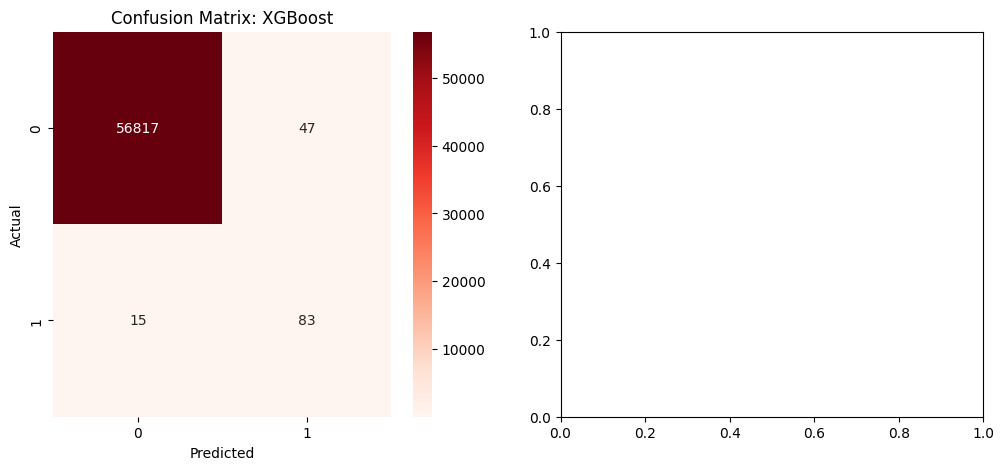

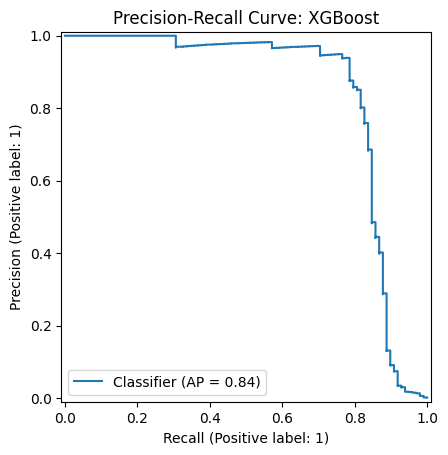

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, PrecisionRecallDisplay

# Visualize results for the current model
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title(f'Confusion Matrix: {name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title(f'Precision-Recall Curve: {name}')
plt.show()

In [28]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import IsolationForest

# Reset results for a clean run if needed, or just continue
# Here we re-calculate the extra models
extra_models_results = []

# 1. LightGBM (on Resampled Data)
print("\n--- Training LightGBM (Resampled) ---")
lgbm = LGBMClassifier(n_jobs=-1, random_state=42)
lgbm.fit(X_train_final, y_train_res)
y_pred_lgbm = lgbm.predict(X_test_final)
y_proba_lgbm = lgbm.predict_proba(X_test_final)[:, 1]

# 2. Isolation Forest (on ORIGINAL Imbalanced Data)
print("\n--- Training Isolation Forest (Original Imbalanced) ---")
# We use X_train_proc which contains the scaled features before SMOTEENN
iso_forest = IsolationForest(contamination=0.0017, random_state=42)
iso_forest.fit(X_train_proc)

# Predict on test set
if_pred = iso_forest.predict(X_test_proc)
y_pred_if = np.where(if_pred == -1, 1, 0)
y_proba_if = -iso_forest.decision_function(X_test_proc)

# Helper to append results
def add_to_results(name, y_true, y_p, y_prob):
    acc = accuracy_score(y_true, y_p)
    auc = roc_auc_score(y_true, y_prob)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_p, average='binary')
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "AUC-ROC": auc}

# Re-assembling the full results list with the updated Isolation Forest
# Assuming results[:3] contained LogReg, RF, and XGB
final_results = results[:3]
final_results.append(add_to_results("LightGBM", y_test, y_pred_lgbm, y_proba_lgbm))
final_results.append(add_to_results("Isolation Forest", y_test, y_pred_if, y_proba_if))

# Final Comparison
comparison_df = pd.DataFrame(final_results)
print("\n--- Final Model Comparison Table ---")
display(comparison_df)


--- Training LightGBM (Resampled) ---
[LightGBM] [Info] Number of positive: 227451, number of negative: 227054
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.133647 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454505, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500437 -> initscore=0.001747
[LightGBM] [Info] Start training from score 0.001747


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Training Isolation Forest (Original Imbalanced) ---

--- Final Model Comparison Table ---


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.972859,0.055283,0.918367,0.104287,0.970231
1,Random Forest,0.999298,0.778846,0.826531,0.801980,0.957725
2,XGBoost,0.998912,0.638462,0.846939,0.728070,0.981351
3,LightGBM,0.998069,0.467742,0.887755,0.612676,0.973486
4,Isolation Forest,0.997577,0.311321,0.336735,0.323529,0.960167


In [29]:
from sklearn.neural_network import MLPClassifier

# 1. Training a Neural Network (Multi-Layer Perceptron)
print("--- Training Neural Network (MLP) ---")
# We use a simple architecture: two hidden layers of 64 and 32 neurons
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_final, y_train_res)

y_pred_mlp = mlp.predict(X_test_final)
y_proba_mlp = mlp.predict_proba(X_test_final)[:, 1]

# Append results to the comparison
mlp_res = add_to_results("Neural Network (MLP)", y_test, y_pred_mlp, y_proba_mlp)
final_results.append(mlp_res)

# Update Comparison Table
comparison_df = pd.DataFrame(final_results)
print("\n--- Updated Model Comparison with Neural Network ---")
display(comparison_df)

--- Training Neural Network (MLP) ---

--- Updated Model Comparison with Neural Network ---


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.972859,0.055283,0.918367,0.104287,0.970231
1,Random Forest,0.999298,0.778846,0.826531,0.801980,0.957725
2,XGBoost,0.998912,0.638462,0.846939,0.728070,0.981351
3,LightGBM,0.998069,0.467742,0.887755,0.612676,0.973486
4,Isolation Forest,0.997577,0.311321,0.336735,0.323529,0.960167
5,Neural Network (MLP),0.998683,0.579310,0.857143,0.691358,0.972649


In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Build the TensorFlow Neural Network
model_tf = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_final.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 2. Compile the model
model_tf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train the model
print("--- Training TensorFlow Dense Neural Network ---")
history = model_tf.fit(
    X_train_final, y_train_res,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# 4. Predict and evaluate
y_proba_tf = model_tf.predict(X_test_final).flatten()
y_pred_tf = (y_proba_tf > 0.5).astype(int)

# Append results to the comparison
tf_res = add_to_results("TensorFlow (Dense NN)", y_test, y_pred_tf, y_proba_tf)
final_results.append(tf_res)

# 5. Display updated results
comparison_df = pd.DataFrame(final_results)
print("\n--- Updated Model Comparison with TensorFlow ---")
display(comparison_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Training TensorFlow Dense Neural Network ---
Epoch 1/10
3196/3196 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9824 - loss: 0.0459 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 2/10
3196/3196 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9976 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 9.2486e-04
Epoch 3/10
3196/3196 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9986 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 7.1784e-04
Epoch 4/10
3196/3196 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9989 - loss: 0.0044 - val_accuracy: 0.9999 - val_loss: 6.6254e-04
Epoch 5/10
3196/3196 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 6/10
3196/3196 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9998 - val_loss: 9.2223e-04
Epoch 7/10
3196/3196 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 0.9982 - val_loss: 0.0043
Epoch 8/10
3196/31

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.972859,0.055283,0.918367,0.104287,0.970231
1,Random Forest,0.999298,0.778846,0.826531,0.801980,0.957725
2,XGBoost,0.998912,0.638462,0.846939,0.728070,0.981351
3,LightGBM,0.998069,0.467742,0.887755,0.612676,0.973486
4,Isolation Forest,0.997577,0.311321,0.336735,0.323529,0.960167
5,Neural Network (MLP),0.998683,0.579310,0.857143,0.691358,0.972649
6,TensorFlow (Dense NN),0.999017,0.664062,0.867347,0.752212,0.974884
